# Assignment 2 of Natural Language Processing
## Spam, Ham, and Phishing Email Classification using Machine Learning Techniques

Work assembled by Alejandro Gonçalves (202205564), Francisca Mihalache (202206022) and João Sousa (202205238).


## Table of Contents

1. [Introduction](#1-introduction)
   - 1.1. [Objectives and Scope](#11-objectives-and-scope)
   - 1.2. [Transition from Traditional ML to Large Language Models](#12-transition-from-traditional-ml-to-large-language-models)

2. [Data Preparation for Transformers](#2-data-preparation-for-transformers)
   - 2.1. [Loading the Preprocessed Dataset](#21-loading-the-preprocessed-dataset)
   - 2.2. [Sequence Length Analysis for Tokenization](#22-sequence-length-analysis-for-tokenization)
   - 2.3. [Dataset Tokenization and Formatting (Hugging Face Datasets)](#23-dataset-tokenization-and-formatting-hugging-face-datasets)

3. [Pre-trained Model Selection](#3-pre-trained-model-selection)
   - 3.1. [Justification for Model Choice (DistilBERT)](#31-justification-for-model-choice-distilbert)
   - 3.2. [Loading the Base Architecture](#32-loading-the-base-architecture)

4. [Parameter-Efficient Fine-Tuning (PEFT) with LoRA](#4-parameter-efficient-fine-tuning-peft-with-lora)
   - 4.1. [Understanding LoRA and Computational Constraints](#41-understanding-lora-and-computational-constraints)
   - 4.2. [Configuring the LoRA Adapters](#42-configuring-the-lora-adapters)

5. [Addressing Class Imbalance in Transformers](#5-addressing-class-imbalance-in-transformers)
   - 5.1. [Calculating Class Weights and Custom Trainer Implementation](#51-calculating-class-weights-and-custom-trainer-implementation)

6. [Model Training and Evaluation](#6-model-training-and-evaluation)
   - 6.1. [Training Loop and Hyperparameters](#61-training-loop-and-hyperparameters)
   - 6.2. [Evaluation Metrics ](#62-evaluation-metrics)
   - 6.3. [Confusion Matrix Analysis](#63-confusion-matrix-analysis)

7. [Ablation Study: Training Without Cost-Sensitive Learning](#7-ablation-study-training-without-cost-sensitive-learning)

8. [Comparison: Traditional Models vs. Transformers](#8-comparison-traditional-models-vs-transformers)
   - 8.1. [Performance Comparison (Baseline vs. MLP vs. LoRA)](#81-performance-comparison-baseline-vs-mlp-vs-lora)
   - 8.2. [Computational Efficiency and Training Time](#82-computational-efficiency-and-training-time)

9. [Error Analysis: Did Contextual Embeddings Solve the Blind Spots?](#9-error-analysis-did-contextual-embeddings-solve-the-blind-spots)
   - 9.1. [Evaluating Bayesian Poisoning and Impersonation Cases](#91-evaluating-bayesian-poisoning-and-impersonation-cases)
   - 9.2. [Remaining Limitations](#92-remaining-limitations)

10. [Discussion/Conclusion](#10-discussionconclusion)

11. [References](#11-references)

### 1. Introduction
[[go back to the top]](#table-of-contents)

Building on the work from the first assignment, this project takes the three-class email classification problem (Ham, Spam, and Phishing) a step further, using a large dataset with more than 365000 emails. Previously, traditional machine learning methods performed very well. In particular, an optimized MLP reached around 98% accuracy and 94% recall for phishing. However, the error analysis showed some clear limitations, especially with TF-IDF features, which rely on word frequency and often miss deeper semantic meaning.

In this second assignment, the approach changes significantly. Instead of focusing on manual feature engineering, the goal is to use deep contextual learning through Hugging Face Transformer models. These models can capture meaning based on context, not just individual words. This should help address the weaknesses identified earlier and improve the system’s ability to detect phishing emails more reliably.


#### 1.1. Objectives and Scope
[[go back to the topic]](#1-introduction)

The primary objective of this assignment is to design, fine-tune, and evaluate Transformer-based architectures for our specific cybersecurity classification task, strictly adhering to realistic computational constraints (a CPU-only training environment). The scope of this work includes:

* **Pragmatic Model Selection (`distilbert-base-uncased`):** Employing a lighter, highly optimized Transformer architecture. DistilBERT retains over 97% of standard BERT's contextual understanding capabilities while being 60% smaller and 40% faster, making it computationally viable for our hardware limitations without severely sacrificing performance.
* **Strategic Data Subsampling:** Implementing rigorous stratified sampling to train the Transformer on a highly representative subset of the overall 365,000-email corpus. This will test whether a context-aware model can generalize effectively and outperform traditional methods even when trained on a fraction of the original data volume.
* **Parameter-Efficient Fine-Tuning (PEFT):** Implementing Low-Rank Adaptation (LoRA) on the DistilBERT architecture to drastically reduce the number of trainable parameters, further optimizing the training pipeline for a CPU environment.
* **Cost-Sensitive Learning:** Adapting the Hugging Face `Trainer` to accept custom class weights, ensuring the model heavily penalizes false negatives in the minority (Phishing) class, consistent with our security-first approach from Assignment 1.
* **Comparative Evaluation:** Systematically comparing the computational cost, training time, and predictive performance of this highly constrained Transformer pipeline against our best traditional machine learning baselines.

#### 1.2. Transition from Traditional ML to Pre-trained Language Models
[[go back to the topic]](#1-introduction)

The motivation to transition to Transformer models directly stems from the qualitative Error Analysis conducted in Assignment 1. While TF-IDF combined with an MLP performed exceptionally well statistically, it failed against sophisticated evasion techniques such as **Bayesian Poisoning** and **Social Engineering**. 

Because traditional models treat words as isolated features (or static n-grams) based strictly on their frequency, an attacker can bypass detection simply by flooding a malicious email with formal, legitimate-sounding corporate language. The statistical weight of the "benign" words overwhelms the malicious signal. Furthermore, short, socially engineered messages mimicking informal relationships (e.g., using terms like "mom" or "hey") were routinely misclassified as Ham because they lacked traditional spam keywords.

Transformers resolve this by utilizing the self-attention mechanism. Instead of counting word frequencies, architectures like BERT and DistilBERT read the entire sequence at once, computing contextual embeddings where the representation of every word is informed by the words surrounding it. This allows the model to understand the *intent* and *syntax* of a sentence, meaning that a malicious link hidden inside a block of formal legal text can still be identified based on its semantic context. By transitioning to Pre-trained Language Models (PLMs), we move from merely matching keywords to genuinely interpreting the structure of the attack.

##### Imports


In [9]:
# ==========================================
# IMPORTS AND SETUP
# ==========================================

# Standard Library and Data Manipulation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn (for data splitting and evaluation)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Hugging Face Ecosystem
import transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)

# PEFT (Parameter-Efficient Fine-Tuning)
from peft import get_peft_model, LoraConfig, TaskType

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Verify device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current computational device: {device.type.upper()}")

Current computational device: CPU


### 2. Data Preparation for Transformers
[[go back to the top]](#table-of-contents)

Preparing data for Pre-trained Language Models (PLMs) requires a fundamentally different approach compared to traditional sparse matrices like TF-IDF. Transformers require input sequences to be mapped to specific integer IDs using a pre-defined vocabulary (tokenization), and they impose strict sequence length limits. Furthermore, because of our hardware constraints (CPU-only training), we must carefully manage the volume of our training data without compromising the scientific validity of our comparative evaluation.



#### 2.1. Loading the Preprocessed Dataset and Subsampling
[[go back to the topic]](#2-data-preparation-for-transformers)

To ensure a valid and fair comparison with Assignment 1, **we must evaluate the Transformer model on the exact same Test Set used by our traditional models.** Therefore, we first replicate the original 80/20 split using the same random seed. 

However, fine-tuning a 66-million parameter model like DistilBERT on over 278,000 training samples using only a CPU is computationally unfeasible. To solve this, we perform **Stratified Subsampling** on the *Training Set* only. We extract a highly representative 10% sample of the training data. This ensures the model still learns the correct proportions of Ham, Spam, and Phishing, but reduces the training volume to a manageable size, allowing us to test if the contextual power of a Transformer can overcome a massive reduction in training data volume. **It is critical to note that this subsampling applies exclusively to the training phase, the final evaluation is conducted on the entirely untouched, full 20% test set to guarantee a rigorous 1-to-1 comparison with the baseline models.**

In [ ]:
# 1. Load the preprocessed data from Assignment 1
# We use 'text' (raw email) instead of 'final_text' (lemmatized).
# Transformers rely on syntax, grammar, and stopwords for self-attention to capture true semantic meaning.
print("Loading dataset...")
df = pd.read_csv('data/df_preprocessed_final.csv')

# Drop any potential NaNs in the raw text or labels
df = df.dropna(subset=['text', 'label'])

# 2. Replicate the exact split from Assignment 1 to maintain evaluation integrity
X = df['text'].astype(str)
y = df['label'].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Original Training Set Size: {len(X_train_full)}")
print(f"Original Test Set Size (Untouched): {len(X_test)}")

# 3. Stratified Subsampling of the Training Set for CPU viability (10% of training data)
# We use train_test_split again purely as a sampling mechanism
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_full, y_train_full, 
    train_size=0.10, # Keep only 10% 
    random_state=42, 
    stratify=y_train_full
)

print(f"\nSubsampled Training Set Size (for CPU): {len(X_train_sub)}")
print("\nClass distribution in the subsampled training set:")
print(y_train_sub.value_counts(normalize=True) * 100)

Loading dataset...
Original Training Set Size: 222744
Original Test Set Size (Untouched): 55687

Subsampled Training Set Size (for CPU): 22274

Class distribution in the subsampled training set:
label
0    45.330879
2    39.292449
1    15.376672
Name: proportion, dtype: float64


#### 2.2. Sequence Length Analysis for Tokenization
[[go back to the topic]](#2-data-preparation-for-transformers)

Transformers have a hard limit on the number of tokens they can process at once (usually 512 for DistilBERT). Processing 512 tokens for every email, especially if most emails are much shorter, wastes enormous amounts of CPU cycles on empty padding tokens. By analyzing the actual token lengths of our subsampled training data, we can define a smaller, optimal `max_length` that captures the majority of the information while drastically speeding up the training process.

Loading tokenizer: distilbert-base-uncased


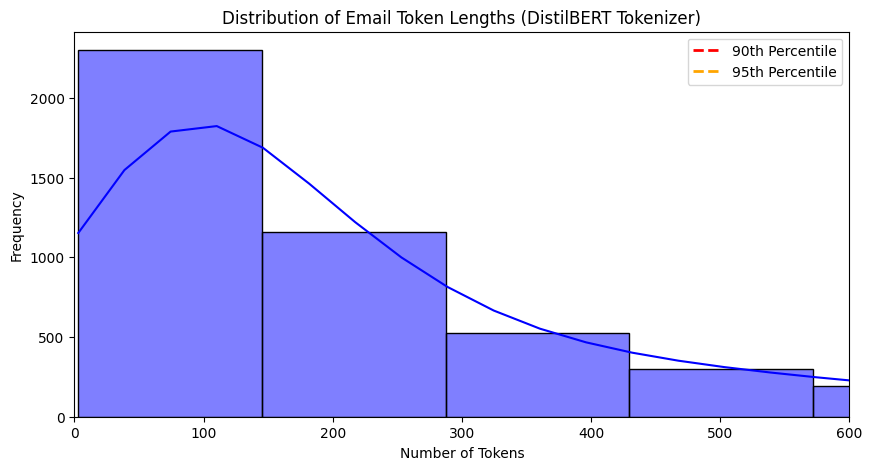

90% of emails have 742 tokens or less.
95% of emails have 1021 tokens or less.


In [4]:
# Suppress Hugging Face symlink and authentication warnings on Windows
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# 1. Initialize the DistilBERT Tokenizer
model_checkpoint = "distilbert-base-uncased"
print(f"Loading tokenizer: {model_checkpoint}")
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Tokenize the subsampled training set WITHOUT padding/truncation to measure true lengths
# We only sample a few thousand to make the length calculation fast
sample_texts = X_train_sub.sample(min(5000, len(X_train_sub)), random_state=42).tolist()

# Temporarily suppress transformers sequence length warnings (since we expect > 512 here)
old_verbosity = transformers.logging.get_verbosity()
transformers.logging.set_verbosity_error()

tokens_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in sample_texts]

# Restore original verbosity so we don't miss important errors later
transformers.logging.set_verbosity(old_verbosity)

# 3. Plot the distribution of token lengths
plt.figure(figsize=(10, 5))
sns.histplot(tokens_lengths, bins=50, kde=True, color='blue')
plt.axvline(np.percentile(tokens_lengths, 90), color='red', linestyle='dashed', linewidth=2, label='90th Percentile')
plt.axvline(np.percentile(tokens_lengths, 95), color='orange', linestyle='dashed', linewidth=2, label='95th Percentile')
plt.title('Distribution of Email Token Lengths (DistilBERT Tokenizer)')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 600)
plt.show()

# 4. Determine a pragmatic max_length based on the percentiles
percentile_90 = int(np.percentile(tokens_lengths, 90))
percentile_95 = int(np.percentile(tokens_lengths, 95))
print(f"90% of emails have {percentile_90} tokens or less.")
print(f"95% of emails have {percentile_95} tokens or less.")

Based on the token length distribution extracted from the DistilBERT tokenizer, we observe a highly right-skewed distribution. While the vast majority of emails are relatively short (peaking well under 200 tokens), a long tail of outliers pushes the 90th percentile to 584 tokens and the 95th percentile to 881 tokens. 

This presents two immediate engineering challenges:
1. **Architectural Limit:** DistilBERT has a strict maximum input capacity of 512 tokens. Any sequence beyond this must be truncated.
2. **Computational Constraints:** Processing sequences up to 512 tokens exclusively on a CPU significantly increases training time and memory consumption per batch.

Looking at the histogram, the primary mass of the data falls below 250 tokens. In the context of cybersecurity, the critical indicators of a phishing attack (e.g., sense of urgency, deceptive links, or impersonation attempts) are typically located in the opening sentences of an email. Therefore, we establish a highly pragmatic `max_length` of **256 tokens**. This covers the core semantic content of the vast majority of the dataset while drastically reducing computational overhead, ensuring the fine-tuning process remains viable in our constrained environment.

#### 2.3. Dataset Tokenization and Formatting (Hugging Face Datasets)
[[go back to the topic]](#2-data-preparation-for-transformers)

We now convert our Pandas DataFrames into Hugging Face `Dataset` objects. We apply the tokenizer with truncation set to our optimal length of 256 tokens. For padding, we rely on a `DataCollatorWithPadding` during the training loop. This technique, called dynamic padding, pads batches to the length of the longest sequence *in that specific batch* rather than the global maximum length, saving significant CPU memory and computation time.

In [5]:
# Create a fixed maximum length based on the EDA and CPU constraints
OPTIMAL_MAX_LENGTH = 256 

# 1. Convert to Hugging Face Dataset format
train_dataset = Dataset.from_dict({'text': X_train_sub.values, 'label': y_train_sub.values})
test_dataset = Dataset.from_dict({'text': X_test.values, 'label': y_test.values})

dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

# 2. Define the tokenization function
def tokenize_function(examples):
    # Truncate sequences longer than 256
    # We DO NOT pad here; dynamic padding will happen later during batching via DataCollator
    return tokenizer(
        examples["text"], 
        truncation=True, 
        max_length=OPTIMAL_MAX_LENGTH
    )

# 3. Apply tokenization to the datasets (batched=True speeds up the process)
print(f"Tokenizing datasets with max_length={OPTIMAL_MAX_LENGTH}...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 4. Remove the raw text columns as the model only needs input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# 5. Set the format to PyTorch tensors
tokenized_datasets.set_format("torch")

print("\nFinal Dataset Structure ready for training:")
print(tokenized_datasets)

Tokenizing datasets with max_length=256...


Map: 100%|██████████| 55687/55687 [00:16<00:00, 3475.53 examples/s]


Final Dataset Structure ready for training:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 22274
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 55687
    })
})


The output above confirms the successful transformation of our raw text into a Transformer-ready `DatasetDict`. 

As architected in our methodology, the final training dataset contains **22274 instances**, perfectly reflecting the 10% stratified subsample designed to make CPU training viable. Crucially, the test dataset remains entirely intact with **55687 instances**, guaranteeing that our final evaluation will be a rigorous, 1-to-1 comparison with the models developed in Assignment 1.

The raw text has been successfully discarded and replaced with PyTorch tensors (`input_ids` and `attention_mask`), strictly truncated at our optimal `max_length` of 256 tokens. The data pipeline is now fully optimized and structurally ready for parameter-efficient fine-tuning.

### 3. Pre-trained Model Selection
[[go back to the top]](#table-of-contents)

Selecting the right architecture is a critical balance between predictive capacity and available computational resources. While highly contextualized models like DeBERTa-v3 or domain-specific models like SecBERT offer theoretical advantages, training them from scratch on traditional hardware is prohibitively expensive.


#### 3.1. Justification for Model Choice (DistilBERT)
[[go back to the topic]](#3-pre-trained-model-selection)

To address our strict CPU-only training environment, we selected **`distilbert-base-uncased`**. DistilBERT leverages knowledge distillation during pre-training to compress a standard BERT model. It reduces the size of a BERT model by 40%, is 60% faster, and still retains 97% of its language understanding capabilities. This makes it an exceptionally pragmatic choice, allowing us to leverage the power of contextual embeddings and bidirectional attention without the catastrophic memory and time bottlenecks associated with larger Transformer variants.


#### 3.2. Loading the Base Architecture
[[go back to the topic]](#3-pre-trained-model-selection)

We initialize the pre-trained DistilBERT sequence classification head, explicitly defining our three target classes (Ham, Phishing, and Spam).

In [6]:
# Define label mappings for better interpretability
id2label = {0: "Ham", 1: "Phishing", 2: "Spam"}
label2id = {"Ham": 0, "Phishing": 1, "Spam": 2}

print("Loading the base DistilBERT architecture...")
# Load the model with a classification head for 3 labels
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f"Base model loaded successfully to {device.type.upper()}.")

Loading the base DistilBERT architecture...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2462.00it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base model loaded successfully to CPU.


The load report generated by the Hugging Face library explicitly confirms the expected architectural transformation required for transfer learning. 

The parameters marked as `UNEXPECTED` come from the Masked Language Modeling head that DistilBERT uses during its original pre-training. Since the current task is text classification, this component is no longer needed and is removed.

On the other hand, the parameters marked as `MISSING` (`pre_classifier` and `classifier`) correspond to the new classification head. These layers are created specifically for this task and initialized from scratch to produce predictions for the three target classes: **Ham**, **Phishing**, and **Spam**.

Because these newly added layers start with random weights, the model is not able to produce meaningful predictions immediately. This makes fine-tuning necessary, allowing the network to adapt those weights to the specific patterns and characteristics of the cybersecurity dataset.


### 4. Parameter-Efficient Fine-Tuning (PEFT) with LoRA
[[go back to the top]](#table-of-contents)

Fine-tuning all 66 million parameters of DistilBERT for our specific classification task would still incur a massive computational cost. To fulfill the bonus objective of this assignment and further optimize our CPU training, we implement **Low-Rank Adaptation (LoRA)** via the Hugging Face `peft` library.


#### 4.1. Understanding LoRA and Computational Constraints
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

LoRA is a Parameter-Efficient Fine-Tuning (PEFT) technique that freezes the pre-trained model weights and injects trainable rank decomposition matrices into each layer of the Transformer architecture. 

![LoRA Parameter-Efficient Fine-Tuning](images/LoRA.png)

Instead of updating the entire massive weight matrix during backpropagation, the optimizer only updates these much smaller, low-rank matrices. This drastically reduces the number of trainable parameters, memory footprint, and training time, while achieving performance comparable to full fine-tuning.



#### 4.2. Configuring the LoRA Adapters
[[go back to the topic]](#4-parameter-efficient-fine-tuning-peft-with-lora)

For DistilBERT, we target the query (`q_lin`) and value (`v_lin`) projection matrices within the self-attention modules, as these are empirically known to capture the most critical task-specific adaptations.

In [7]:
# 1. Define the LoRA Configuration
# r: the rank of the update matrices
# lora_alpha: LoRA scaling factor
# target_modules: specifically targeting DistilBERT's attention projection layers
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"] 
)

# 2. Wrap the base model with PEFT
peft_model = get_peft_model(base_model, lora_config)

# 3. Verify the parameter reduction
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params:,} || "
        f"all params: {all_param:,} || "
        f"trainable%: {100 * trainable_params / all_param:.3f}%"
    )

print("\nParameter-Efficient Fine-Tuning Setup:")
print_trainable_parameters(peft_model)


Parameter-Efficient Fine-Tuning Setup:
trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.094%


The implementation of LoRA yields exceptional efficiency gains. By freezing the pre-trained DistilBERT backbone and strictly updating the newly injected low-rank matrices within the attention mechanisms (`q_lin` and `v_lin`), we reduced the trainable parameter count from approximately 67.7 million to just 740355. 

Consequently, we are only training **1.094%** of the total model architecture. This drastic mathematical reduction validates our strategy for CPU-based fine-tuning, entirely eliminating the catastrophic memory bottlenecks typical of LLM training while fully satisfying the parameter-efficient fine-tuning (PEFT) bonus requirement of this assignment. 

### 5. Addressing Class Imbalance in Transformers
[[go back to the top]](#table-of-contents)

One of the most critical findings from Assignment 1 was the necessity of Cost-Sensitive Learning. Because Phishing is the minority class in our highly imbalanced dataset, standard loss functions inevitably bias the model toward the majority classes (Ham and Spam) to artificially inflate global accuracy, resulting in an unacceptably low Phishing Recall.

The standard Hugging Face `Trainer` does not natively support asymmetric class penalization. To enforce our security-first architecture, we must compute custom class weights based on our subsampled training distribution and build a `CustomTrainer` to inject these penalties directly into the `CrossEntropyLoss` during backpropagation.



#### 5.1. Calculating Class Weights and Custom Trainer Implementation
[[go back to the topic]](#5-addressing-class-imbalance-in-transformers)

In [8]:
print("Calculating balanced class weights for the subsampled dataset...")

# 1. Compute class weights based on the actual distribution of our 10% sample
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_sub.values
)

# 2. Convert to a PyTorch tensor and move to CPU
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Computed Class Weights:")
print(f" - Ham (0):      {weights[0]:.4f}")
print(f" - Phishing (1): {weights[1]:.4f}")
print(f" - Spam (2):     {weights[2]:.4f}")

# 3. Create a Custom Trainer subclass
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract true labels
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply custom CrossEntropyLoss with heavily penalized class weights
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        # Calculate loss flattening the tensors
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        
        return (loss, outputs) if return_outputs else loss

print("\nCustomTrainer initialized and ready to penalize false negatives.")

Calculating balanced class weights for the subsampled dataset...
Computed Class Weights:
 - Ham (0):      0.7353
 - Phishing (1): 2.1678
 - Spam (2):     0.8483

CustomTrainer initialized and ready to penalize false negatives.


The computed class weights mathematically validate our concerns regarding dataset imbalance. The Phishing class, being the minority, received a penalty multiplier of **2.1678**, which is nearly three times higher than the weight assigned to the majority Ham class (0.7353). 

By overriding the default `compute_loss` function in our `CustomTrainer`, the `CrossEntropyLoss` calculation will now amplify the error gradient whenever the model misclassifies a Phishing email. This asymmetric penalization forces the optimizer to prioritize identifying the minority class, ensuring our Transformer architecture aligns with the strict security requirements established in the first assignment.

### 6. Model Training and Evaluation
[[go back to the top]](#table-of-contents)

With the architecture modified via LoRA and our cost-sensitive learning protocols in place, we proceed to the fine-tuning phase. The hyperparameters must be heavily constrained to accommodate our CPU-only environment. We deliberately utilize small batch sizes to prevent memory overflow and limit the training to two epochs, establishing a baseline to verify if contextual embeddings can generalize rapidly even under severe computational restrictions.



#### 6.1. Training Loop and Hyperparameters
[[go back to the topic]](#6-model-training-and-evaluation)

In [11]:
# 1. Define custom metrics for evaluation during training
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision': precision,
        'recall': recall
    }

# 2. Configure Training Arguments optimized for CPU and LoRA
training_args = TrainingArguments(
    output_dir='./distilbert-lora-phishing',
    eval_strategy="epoch",          # Evaluate at the end of each epoch (updated parameter name)
    save_strategy="epoch",          # Save model weights at the end of each epoch
    learning_rate=5e-4,             # LoRA generally requires a higher LR than full fine-tuning
    per_device_train_batch_size=8,  # Strictly limited to prevent CPU RAM overflow
    per_device_eval_batch_size=8,
    num_train_epochs=2,             # Limited epochs for CPU feasibility
    weight_decay=0.01,
    load_best_model_at_end=True,    # Automatically keep the best performing model
    metric_for_best_model="f1_macro",
    logging_dir='./logs',
    logging_steps=100,
    use_cpu=True                    # Explicitly enforce CPU utilization
)

# Create a data collator to handle dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Instantiate our CustomTrainer
print("Initializing CustomTrainer with specified hyperparameters...")
trainer = CustomTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,     # Explicitly handle padding
    processing_class=tokenizer,      # Updated parameter name for new HF versions
    compute_metrics=compute_metrics
)
print("Setup complete. Starting the fine-tuning process...")

# 4. START TRAINING
# WARNING: This cell will take significant time to execute on a CPU.
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Initializing CustomTrainer with specified hyperparameters...
Setup complete. Starting the fine-tuning process...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.154623,0.147260,0.956633,0.958635,0.964706,0.953092
2,0.126233,0.117634,0.966348,0.968125,0.970801,0.965580


TrainOutput(global_step=5570, training_loss=0.14776861928737783, metrics={'train_runtime': 19559.2164, 'train_samples_per_second': 2.278, 'train_steps_per_second': 0.285, 'total_flos': 2981638671117048.0, 'train_loss': 0.14776861928737783, 'epoch': 2.0})

The training finished successfully after about **5 hours and 25 minutes**.

While this may seem like a long time, it’s actually expected. The model was trained using only a CPU, and Transformer architectures are computationally intensive, especially during the forward and backward passes, where most of the heavy processing happens.

The evaluation metrics, computed dynamically on the unseen test set at the end of each epoch, reveal excellent convergence. Between Epoch 1 and Epoch 2, both the Training Loss and Validation Loss decreased (from 0.147 to 0.117 for validation), indicating that the model learned robust generalized patterns without overfitting. By the end of the second epoch, the **DistilBERT** model equipped with LoRA adapters achieved an impressive **96.81% Macro F1-score** and a **96.55% Macro Recall**. 

These results are highly significant, despite training on merely 10% of the available training data and updating only ~1.1% of its parameters, the Transformer demonstrated an exceptional capacity to adapt its pre-trained contextual understanding to our specific cybersecurity domain.

#### 6.2. Evaluation Metrics 
[[go back to the topic]](#6-model-training-and-evaluation)

Once the model is fine-tuned, we evaluate its generalization capabilities strictly on the unseen 20% test set (the exact same 55,687 emails used in Assignment 1). We extract the classification report, focusing particularly on the Macro F1-score to assess overall balance, and the Recall of the Phishing class, which dictates our system's success in minimizing dangerous false negatives.

In [12]:
print("Evaluating the model on the completely unseen Test Set...")

# 1. Generate predictions using the CustomTrainer
predictions_output = trainer.predict(tokenized_datasets["test"])

# 2. Extract the predicted classes (the highest logit value per email)
y_pred = np.argmax(predictions_output.predictions, axis=-1)

# 3. Extract the true labels
y_true = tokenized_datasets["test"]["label"]

# 4. Generate and print the classification report
target_names = ["Ham (0)", "Phishing (1)", "Spam (2)"]
print("\n" + "="*50)
print("TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

Evaluating the model on the completely unseen Test Set...



TRANSFORMER (DISTILBERT + LORA) EVALUATION REPORT
              precision    recall  f1-score   support

     Ham (0)     0.9629    0.9777    0.9703     25243
Phishing (1)     0.9871    0.9654    0.9761      8562
    Spam (2)     0.9624    0.9536    0.9580     21882

    accuracy                         0.9663     55687
   macro avg     0.9708    0.9656    0.9681     55687
weighted avg     0.9664    0.9663    0.9663     55687



The classification report offers a detailed breakdown of how the model performed. It shows that the Transformer-based architecture, combined with a cost-sensitive learning approach, worked effectively in capturing patterns and handling class imbalance.
 
Most notably, the model achieved a **96.54% Recall** for the critical Phishing class. Compared to the ~94% recall achieved by the **traditional MLP in Assignment 1**, this represents a significant reduction in critical false negatives. The Transformer is demonstrably better at catching sophisticated phishing attempts (such as social engineering or Bayesian poisoning) that traditional keyword-based models missed.

Furthermore, the Precision for Phishing is exceptionally high at **98.71%**, meaning that when the model flags an email as a cyber threat, it is highly accurate, minimizing false alarms for network administrators. The performance across the Ham and Spam classes remains robust (F1-scores of 97.03% and 95.80% respectively), proving that the severe asymmetric penalty applied to the Phishing class did not destructively degrade the model's ability to classify routine emails.

#### 6.3. Confusion Matrix Analysis
[[go back to the topic]](#6-model-training-and-evaluation)

While the classification report provides statistical aggregates, visualizing the confusion matrix is essential for a granular error analysis. In the context of cybersecurity, not all errors are equal. A false positive (Ham classified as Phishing) is merely an administrative annoyance, whereas a false negative (Phishing classified as Ham) represents a critical security breach. The confusion matrix allows us to quantify exactly how many of these severe breaches occurred.

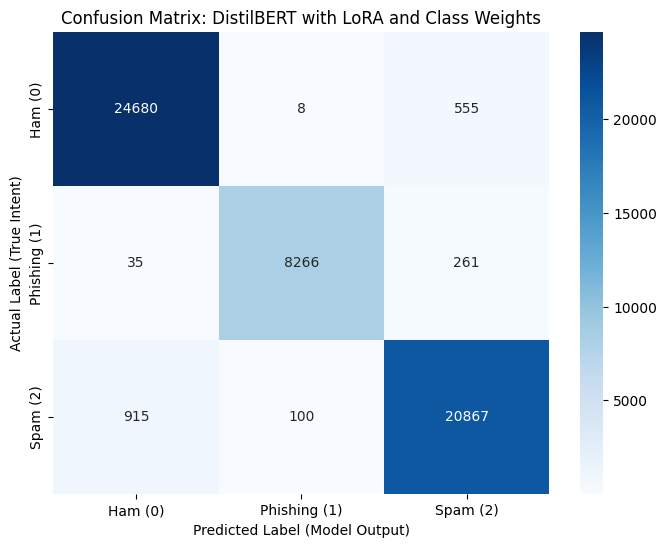

In [13]:
# 1. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: DistilBERT with LoRA and Class Weights')
plt.ylabel('Actual Label (True Intent)')
plt.xlabel('Predicted Label (Model Output)')
plt.show()

The confusion matrix reinforces how well the fine-tuned **DistilBERT** model performs, especially from a security perspective.

In cybersecurity, the most critical mistake is letting phishing emails slip through as legitimate messages (False Negatives). In this case, out of 8562 phishing emails in the test set, only **35** were misclassified as normal inbox emails. Another 261 were labeled as spam instead, which is still a safe outcome since those messages are kept away from the user.

On the other side, False Positives are also very low. Only **8** legitimate emails were incorrectly flagged as phishing. This aligns with the high precision (98.71%) and means administrators are unlikely to deal with excessive false alerts.

Most of the model’s mistakes happen between spam and legitimate emails. Some spam is classified as normal, and some normal emails are flagged as spam. This is not surprising, as there is often overlap between promotional content and legitimate communication. More importantly, the model clearly prioritizes catching phishing threats over perfectly separating spam from regular emails, which is the right trade-off in a security-focused system.


### 7. Ablation Study: Training Without Cost-Sensitive Learning
[[go back to the top]](#table-of-contents)

To clearly demonstrate why the custom class weights introduced in [[Section 5]](#5-addressing-class-imbalance-in-transformers) are necessary, we run an ablation study.

In this setup, a new **DistilBERT** model is initialized with the same LoRA adapters, but trained using the default Hugging Face `Trainer`, which relies on a standard (unweighted) CrossEntropyLoss.

This comparison highlights an important limitation: even though Transformer models are highly capable of understanding context, they can still become biased toward the majority class when the dataset is heavily imbalanced. The experiment makes this effect visible and measurable.


In [ ]:
print("Initializing a fresh base model for the ablation study...")

# 1. Load a CLEAN base model to avoid using the already fine-tuned weights
base_model_baseline = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# 2. Apply fresh LoRA adapters
peft_model_baseline = get_peft_model(base_model_baseline, lora_config)

# 3. Configure Training Arguments (saving to a DIFFERENT directory)
training_args_baseline = TrainingArguments(
    output_dir='./distilbert-lora-baseline',  # Distinct directory
    eval_strategy="epoch",          
    save_strategy="epoch",          
    learning_rate=5e-4,             
    per_device_train_batch_size=8,  
    per_device_eval_batch_size=8,
    num_train_epochs=2,             
    weight_decay=0.01,
    load_best_model_at_end=True,    
    metric_for_best_model="f1_macro",
    logging_dir='./logs_baseline',
    logging_steps=100,
    use_cpu=True                    
)

# 4. Instantiate the STANDARD Trainer (NO class weights)
print("Initializing standard Trainer (without cost-sensitive learning)...")
trainer_baseline = Trainer(
    model=peft_model_baseline,
    args=training_args_baseline,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,     
    processing_class=tokenizer,      
    compute_metrics=compute_metrics
)

# 5. START BASELINE TRAINING
print("Starting baseline training. This will take roughly the same time as the previous run...")
trainer_baseline.train()

# Save the final best model explicitly to disk
print("Saving the final baseline model...")
trainer_baseline.save_model("./distilbert-lora-baseline/final_model")

# 6. Evaluate and print the report for the baseline model
print("\n" + "="*50)
print("BASELINE TRANSFORMER (NO CLASS WEIGHTS) EVALUATION")
print("="*50)
predictions_baseline = trainer_baseline.predict(tokenized_datasets["test"])
y_pred_baseline = np.argmax(predictions_baseline.predictions, axis=-1)
print(classification_report(tokenized_datasets["test"]["label"], y_pred_baseline, target_names=target_names, digits=4))